# EDA: Exploratory Data Analysis

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = pd.read_csv('../data/cleaned_data.csv')
df_encoded = pd.read_csv('../data/encoded_data.csv')

In [6]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

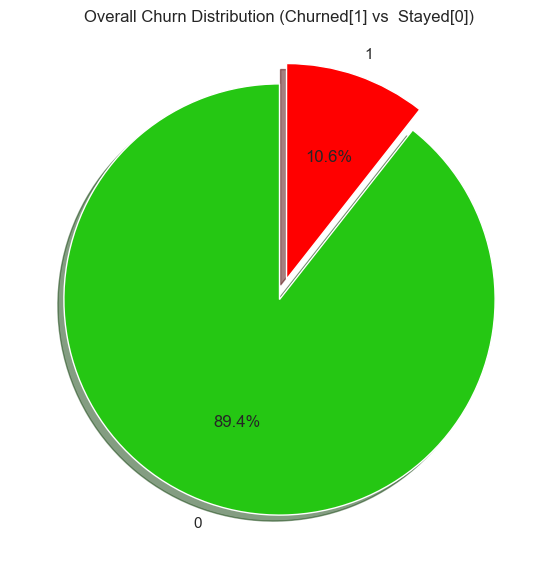

In [24]:
# ---------------------------------------------------------
# Churn Distribution
# ---------------------------------------------------------
plt.figure(figsize=(7, 7))
df['Churn'].value_counts().plot.pie(
    explode=[0, 0.1], 
    autopct='%1.1f%%', 
    shadow=True, 
    colors=["#25c713","#ff0000"],
    startangle=90
)
plt.title('Overall Churn Distribution (Churned[1] vs  Stayed[0])')
plt.ylabel('')
plt.show()

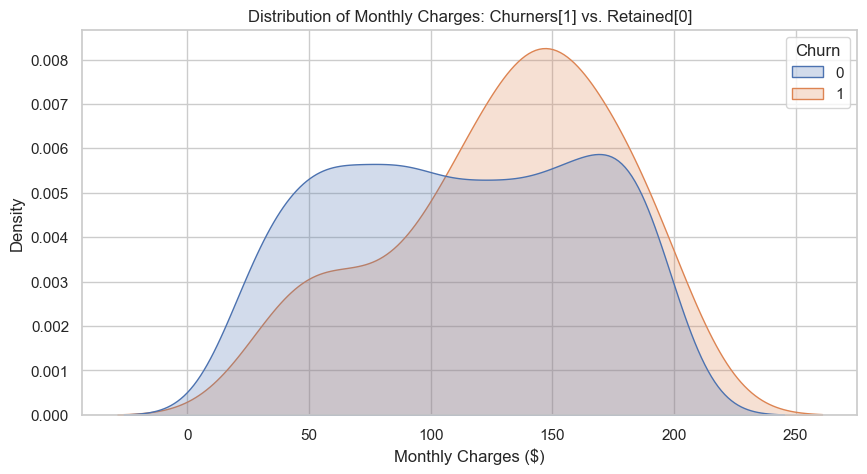

In [22]:
# ---------------------------------------------------------
#  THE PRICE TRAP: Monthly Charges vs. Churn
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='deep')
plt.title('Distribution of Monthly Charges: Churners[1] vs. Retained[0]')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.show()

As we can see in the above chart, the customer churned when the monthly charges are in around $150. Even though some customer are willing to stay with high monthly charges, which is around $180.

But the count of the churned is high.

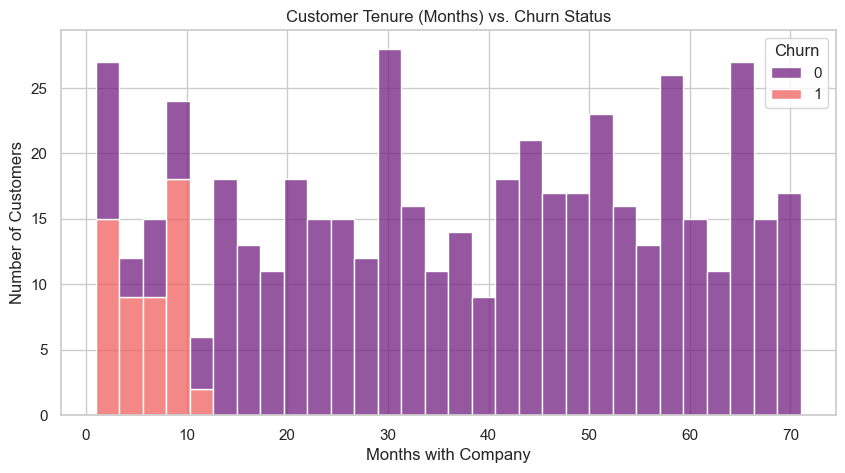

In [26]:
# ---------------------------------------------------------
# THE LOYALTY FACTOR: Tenure vs. Churn
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Tenure', hue='Churn', multiple="stack", palette='magma', bins=30)
plt.title('Customer Tenure (Months) vs. Churn Status')
plt.xlabel('Months with Company')
plt.ylabel('Number of Customers')
plt.show()

by this above we can say that the customer who are having tenure for less than 11-12 months are highly to leave or churned.

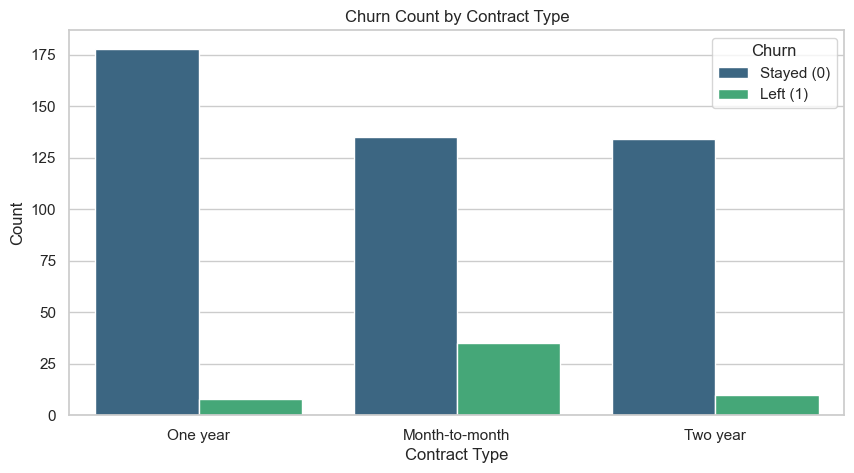

In [ ]:
# ---------------------------------------------------------
#  THE CONTRACT EFFECT: Contract Type vs. Churn
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['Stayed (0)', 'Left (1)'])
plt.show()

By this above chart we can say that the count of the churned is higher when the contract type is month-to-month.

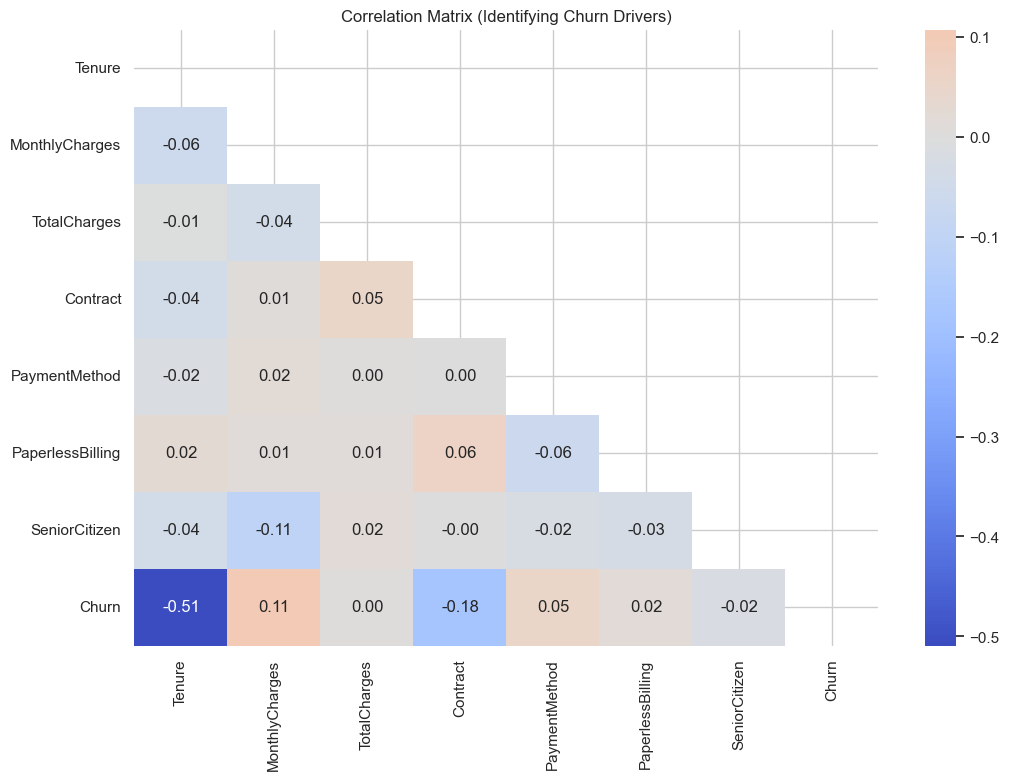

In [ ]:
# ---------------------------------------------------------
#  THE CORRELATION MAP (The Smoking Gun)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# We also use numeric_only=True to be extra safe.
corr = df_encoded.drop(columns=['CustomerID']).corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Identifying Churn Drivers)')
plt.show()

We only need the Churn row(at the bottom of image).

By this we can tell that Churn column is highly effectef by by the 'Tenure' and 'contract'. bcuz of there negative correlation